# CardioIA – Fase 2: Diagnóstico Automatizado
### Parte 1 – Extração de sintomas e sugestão de diagnóstico
### Parte 2 – Classificador de risco com TF-IDF + Machine Learning

---
## PARTE 1 – Leitura de sintomas e sugestão de diagnóstico

In [2]:
import pandas as pd
import os

# ─── 1. Carrega o mapa de conhecimento ────────────────────────────────────────
# O CSV associa sintomas (colunas sintoma_1, sintoma_2, sintoma_3) a uma doença.
# Cada linha é uma 'regra': se o texto do paciente contiver esses termos → sugere a doença.
csv_path = os.path.join('../', 'assets', 'DataSet', 'parte1', 'conhecimento.csv')
conhecimento = pd.read_csv(csv_path)
print('Mapa de conhecimento carregado:', conhecimento.shape[0], 'regras')
conhecimento.head()

Mapa de conhecimento carregado: 40 regras


,sintoma_1,sintoma_2,sintoma_3,doenca,gravidade,especialidade
0,dor no peito,aperto no tórax,dor em repouso,Angina Instável,alta,Cardiologia
1,dor no peito ao esforço,melhora com repouso,aperto no peito,Angina Estável,moderada,Cardiologia
2,dor no peito,irradiação para o braço esquerdo,suor frio,Infarto Agudo do Miocárdio,altíssima,Cardiologia
3,dor no peito,irradiação para o maxilar,sensação de morte iminente,Infarto Agudo do Miocárdio,altíssima,Cardiologia
4,dor no peito,irradiação para o pescoço,náusea,Infarto Agudo do Miocárdio,altíssima,Cardiologia


In [ ]:
# ─── 2. Carrega as frases de sintomas ────────────────────────────────────────
# Cada linha do .txt é um relato de paciente.
txt_path = os.path.join('../', 'assets', 'DataSet', 'parte1', 'sintomas.txt')
with open(txt_path, 'r', encoding='utf-8') as f:
    linhas = f.readlines()

# Remove numeração inicial (ex: "1. ") e espaços extras
frases = []
for linha in linhas:
    linha = linha.strip()
    if linha:  # ignora linhas vazias
        # Remove o número e o ponto no início (ex: "1. ")
        if linha[0].isdigit():
            linha = linha.split('.', 1)[-1].strip()
        frases.append(linha)

print(f'Total de frases carregadas: {len(frases)}')
for i, f_ in enumerate(frases[:5], 1):
    print(f'  [{i}] {f_}')

Total de frases carregadas: 30
  [1] Há dois dias estou com uma dor no peito que piora quando faço esforço físico e sinto um aperto no tórax que não passa nem em repouso.
  [2] Sinto cansaço constante há uma semana, mesmo depois de dormir bastante, e fico sem fôlego ao subir um lance de escadas.
  [3] Estou com falta de ar desde ontem à noite e sinto dificuldade para respirar mesmo quando estou deitado, preciso de dois travesseiros para conseguir dormir.
  [4] Tenho sentido palpitações no coração, como se ele estivesse acelerado e irregular, junto com tontura e suor frio nas mãos.
  [5] Desde manhã cedo estou com uma dor no peito que irradia para o braço esquerdo e para o maxilar, com suor excessivo e sensação de que algo muito grave está acontecendo.


In [5]:
# ─── 3. Função de extração e diagnóstico ─────────────────────────────────────
# Lógica: para cada frase do paciente, verifica se os sintomas da regra aparecem no texto.
# Conta quantos sintomas da regra estão presentes → escolhe a regra com mais correspondências.

def diagnosticar(frase: str, conhecimento: pd.DataFrame) -> dict:
    """Retorna o diagnóstico com mais sintomas identificados na frase."""
    frase_lower = frase.lower()  # normaliza para minúsculas
    
    melhor_pontuacao = 0
    melhor_linha = None
    sintomas_encontrados = []

    for _, linha in conhecimento.iterrows():
        pontuacao = 0
        achados = []

        # Verifica cada coluna de sintoma
        for col in ['sintoma_1', 'sintoma_2', 'sintoma_3']:
            sintoma = str(linha[col]).lower()
            if sintoma and sintoma != 'nan':
                # Verifica se as palavras-chave do sintoma estão na frase
                palavras_chave = sintoma.split()
                if all(p in frase_lower for p in palavras_chave):
                    pontuacao += 1
                    achados.append(sintoma)
                # Verificação parcial (pelo menos metade das palavras)
                elif sum(1 for p in palavras_chave if p in frase_lower) >= len(palavras_chave) / 2:
                    pontuacao += 0.5
                    achados.append(f'{sintoma} (parcial)')

        if pontuacao > melhor_pontuacao:
            melhor_pontuacao = pontuacao
            melhor_linha = linha
            sintomas_encontrados = achados

    if melhor_linha is not None and melhor_pontuacao > 0:
        return {
            'diagnostico': melhor_linha['doenca'],
            'gravidade': melhor_linha['gravidade'],
            'especialidade': melhor_linha['especialidade'],
            'sintomas_identificados': sintomas_encontrados,
            'pontuacao': melhor_pontuacao
        }
    else:
        return {
            'diagnostico': 'Não identificado – encaminhar para avaliação clínica',
            'gravidade': 'desconhecida',
            'especialidade': 'Clínica Geral',
            'sintomas_identificados': [],
            'pontuacao': 0
        }

print('Função de diagnóstico definida com sucesso.')

Função de diagnóstico definida com sucesso.


In [6]:
# ─── 4. Aplica o diagnóstico a todas as frases e exibe os resultados ──────────
print('=' * 70)
print('RESULTADOS DO DIAGNÓSTICO ASSISTIDO POR IA – CardioIA')
print('=' * 70)

resultados = []
for i, frase in enumerate(frases, 1):
    resultado = diagnosticar(frase, conhecimento)
    resultados.append({'paciente': i, 'frase': frase, **resultado})
    
    print(f'\n[Paciente {i:02d}]')
    print(f'  Relato  : {frase[:90]}...' if len(frase) > 90 else f'  Relato  : {frase}')
    print(f'  Sintomas: {resultado["sintomas_identificados"]}')
    print(f'  ► Diagnóstico sugerido : {resultado["diagnostico"]}')
    print(f'  ► Gravidade            : {resultado["gravidade"]}')
    print(f'  ► Especialidade        : {resultado["especialidade"]}')

RESULTADOS DO DIAGNÓSTICO ASSISTIDO POR IA – CardioIA

[Paciente 01]
  Relato  : Há dois dias estou com uma dor no peito que piora quando faço esforço físico e sinto um ap...
  Sintomas: ['dor no peito', 'aperto no tórax', 'dor em repouso']
  ► Diagnóstico sugerido : Angina Instável
  ► Gravidade            : alta
  ► Especialidade        : Cardiologia

[Paciente 02]
  Relato  : Sinto cansaço constante há uma semana, mesmo depois de dormir bastante, e fico sem fôlego ...
  Sintomas: ['cansaço constante', 'sem fôlego ao esforço (parcial)']
  ► Diagnóstico sugerido : Insuficiência Cardíaca
  ► Gravidade            : alta
  ► Especialidade        : Cardiologia

[Paciente 03]
  Relato  : Estou com falta de ar desde ontem à noite e sinto dificuldade para respirar mesmo quando e...
  Sintomas: ['falta de ar deitado', 'precisa de travesseiros para dormir (parcial)']
  ► Diagnóstico sugerido : Insuficiência Cardíaca
  ► Gravidade            : alta
  ► Especialidade        : Cardiologia

[Pacie

In [7]:
# ─── 5. Exporta os resultados para CSV ───────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv('resultados_diagnostico.csv', index=False, encoding='utf-8-sig')
print('Arquivo resultados_diagnostico.csv salvo com sucesso.')

Arquivo resultados_diagnostico.csv salvo com sucesso.


---
## PARTE 2 – Classificador de risco com TF-IDF e Machine Learning

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, recall_score, f1_score
)
import matplotlib.pyplot as plt
import joblib
import numpy as np

# ─── 1. Carrega o dataset de triagem ─────────────────────────────────────────
# Cada linha tem uma frase médica e o rótulo: 'alto risco' ou 'baixo risco'
csv_path2 = os.path.join('../', 'assets', 'DataSet', 'parte2', 'triagem.csv')
triagem = pd.read_csv(csv_path2)
print(f'Dataset carregado: {triagem.shape[0]} amostras')
print(triagem['situacao'].value_counts())
triagem.head()

Dataset carregado: 79 amostras
situacao
baixo risco    49
alto risco     30
Name: count, dtype: int64


,frase,situacao
0,sinto dor no peito intensa com irradiação para...,alto risco
1,tenho aperto no tórax há uma hora que não pass...,alto risco
2,acordei com falta de ar intensa e sensação de ...,alto risco
3,sinto pressão forte no peito com náusea e form...,alto risco
4,tenho dor no peito que irradia para o maxilar ...,alto risco


In [ ]:
    # ─── 2. Divide os dados em treino e teste ────────────────────────────────────
    # X = frases (entrada), y = rótulo de risco (saída esperada)
    X = triagem['frase']
    y = triagem['situacao']

    # 80% treino / 20% teste, com estratificação para balancear as classes
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    print(f'Amostras de treino : {len(X_treino)}')
    print(f'Amostras de teste  : {len(X_teste)}')

Amostras de treino : 63
Amostras de teste  : 16


In [10]:
# ─── 3. Vetorização com TF-IDF ────────────────────────────────────────────────
# TF-IDF transforma texto em números.
# TF (Term Frequency): quão frequente a palavra é no documento.
# IDF (Inverse Document Frequency): quão rara ela é no conjunto todo.
# Palavras muito comuns (como 'sinto', 'tenho') recebem peso menor.
# Palavras específicas (como 'irradiação', 'sufocamento') recebem peso maior.

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # considera palavras individuais E pares de palavras
    max_features=500,    # usa as 500 combinações mais relevantes
    sublinear_tf=True    # aplica log na frequência, reduzindo dominância de palavras repetidas
)

# Aprende o vocabulário APENAS com os dados de treino (evita data leakage)
X_treino_vec = tfidf.fit_transform(X_treino)
# Aplica a mesma transformação nos dados de teste
X_teste_vec = tfidf.transform(X_teste)

print(f'Dimensão dos vetores: {X_treino_vec.shape}')
print(f'(linhas=amostras, colunas=features TF-IDF)')

Dimensão dos vetores: (63, 500)
(linhas=amostras, colunas=features TF-IDF)


In [23]:
# ─── 4. Treina e avalia dois modelos ─────────────────────────────────────────
# Modelo A: Regressão Logística
# Calcula a probabilidade de cada classe com base nos pesos aprendidos.
# Boa escolha quando há relação linear entre features e saída.

# Modelo B: Árvore de Decisão
# Cria regras do tipo 'SE x ENTÃO y'.
# Fácil de visualizar e interpretar.

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Árvore de Decisão'  : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Regressão Balanceada': LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
    'Árvore de Decisão Balanceada'  : DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
}

resultados_modelos = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino_vec, y_treino)
    y_pred = modelo.predict(X_teste_vec)
    acc = accuracy_score(y_teste, y_pred)
    resultados_modelos[nome] = {'modelo': modelo, 'y_pred': y_pred, 'acuracia': acc}

    print(f'\n{"="*55}')
    print(f'  MODELO: {nome}')
    print(f'{"="*55}')
    print(f'  Acurácia: {acc:.2%}')
    print()
    print(classification_report(y_teste, y_pred))


  MODELO: Regressão Logística
  Acurácia: 75.00%

              precision    recall  f1-score   support

  alto risco       1.00      0.33      0.50         6
 baixo risco       0.71      1.00      0.83        10

    accuracy                           0.75        16
   macro avg       0.86      0.67      0.67        16
weighted avg       0.82      0.75      0.71        16


  MODELO: Árvore de Decisão
  Acurácia: 81.25%

              precision    recall  f1-score   support

  alto risco       0.80      0.67      0.73         6
 baixo risco       0.82      0.90      0.86        10

    accuracy                           0.81        16
   macro avg       0.81      0.78      0.79        16
weighted avg       0.81      0.81      0.81        16


  MODELO: Regressão Balanceada
  Acurácia: 93.75%

              precision    recall  f1-score   support

  alto risco       1.00      0.83      0.91         6
 baixo risco       0.91      1.00      0.95        10

    accuracy                  

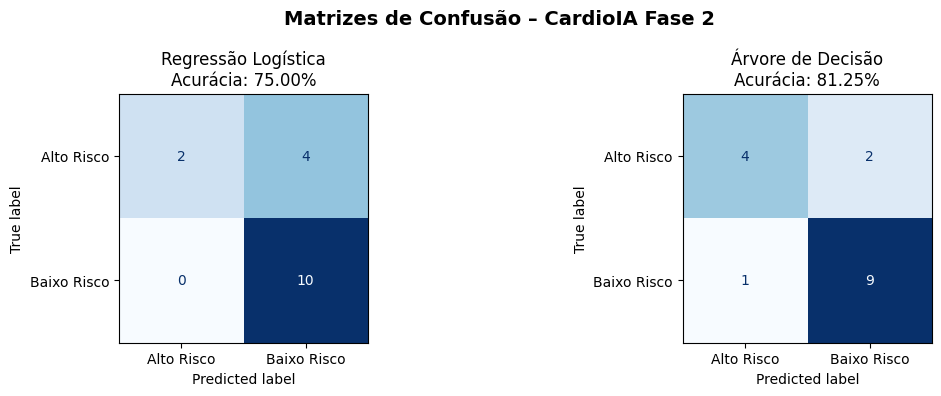

Gráfico salvo como matrizes_confusao.png


In [16]:
# ─── 5. Matrizes de confusão ──────────────────────────────────────────────────
# A matriz de confusão mostra:
# - Verdadeiros Positivos (acertou alto risco)
# - Verdadeiros Negativos (acertou baixo risco)
# - Falsos Positivos (disse alto risco mas era baixo) → menos perigoso
# - Falsos Negativos (disse baixo risco mas era alto) → CRÍTICO em saúde!

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matrizes de Confusão – CardioIA Fase 2', fontsize=14, fontweight='bold')

for ax, (nome, res) in zip(axes, resultados_modelos.items()):
    cm = confusion_matrix(y_teste, res['y_pred'], labels=['alto risco', 'baixo risco'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Alto Risco', 'Baixo Risco'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nAcurácia: {res["acuracia"]:.2%}')

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo como matrizes_confusao.png')

In [27]:
# ─── Cross-validation 5-fold nos quatro modelos ──────────────────────────────
# StratifiedKFold garante que cada fold mantém a proporção de classes
# (alto risco / baixo risco) — importante com dataset desbalanceado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas que queremos medir em cada fold
scoring = {
    'accuracy'   : 'accuracy',
    'recall_alto': make_scorer(recall_score, pos_label='alto risco'),
    'f1_alto'    : make_scorer(f1_score,     pos_label='alto risco'),
}

# Pipeline junta TF-IDF + modelo num objeto só
# Isso evita data leakage: o TF-IDF aprende o vocabulário
# apenas com o treino de cada fold, nunca vê o teste antes
modelos_cv = {
    'Regressão Logística'  : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Árvore de Decisão'    : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Regressão Balanceada' : LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
    'Árvore Balanceada'    : DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
}

print('=' * 75)
print('  CROSS-VALIDATION 5-FOLD — comparação completa')
print('=' * 75)
print(f'  {"Modelo":<24} | {"Acurácia":^16} | {"Recall alto":^16} | {"F1 alto":^12}')
print('-' * 75)

for nome, modelo in modelos_cv.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=500, sublinear_tf=True)),
        ('clf', modelo)
    ])
    
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    
    acc = res['test_accuracy']
    rec = res['test_recall_alto']
    f1  = res['test_f1_alto']
    
    print(f'  {nome:<24} | {acc.mean():.1%} ± {acc.std():.1%}   | {rec.mean():.1%} ± {rec.std():.1%}   | {f1.mean():.1%} ± {f1.std():.1%}')

print('=' * 75)
print()
print('Interpretação do ± : desvio padrão entre os 5 folds.')
print('Quanto menor, mais estável o modelo entre diferentes divisões dos dados.')

  CROSS-VALIDATION 5-FOLD — comparação completa
  Modelo                   |     Acurácia     |   Recall alto    |   F1 alto   
---------------------------------------------------------------------------
  Regressão Logística      | 83.6% ± 7.4%   | 56.7% ± 20.0%   | 70.2% ± 17.0%
  Árvore de Decisão        | 88.8% ± 9.2%   | 80.0% ± 12.5%   | 84.2% ± 12.5%
  Regressão Balanceada     | 97.5% ± 3.1%   | 93.3% ± 8.2%   | 96.4% ± 4.5%
  Árvore Balanceada        | 84.7% ± 7.6%   | 76.7% ± 8.2%   | 79.6% ± 9.8%

Interpretação do ± : desvio padrão entre os 5 folds.
Quanto menor, mais estável o modelo entre diferentes divisões dos dados.


In [31]:
tfidf_final = TfidfVectorizer(ngram_range=(1,2), max_features=500, sublinear_tf=True)
X_full_vec = tfidf_final.fit_transform(triagem['frase'])

modelo_salvo = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
modelo_salvo.fit(X_full_vec, triagem['situacao'])

joblib.dump(modelo_salvo, 'cardioia_modelo.pkl')
joblib.dump(tfidf_final,  'cardioia_tfidf.pkl')

print('Modelo salvo: cardioia_modelo.pkl')
print('Vetorizador salvo: cardioia_tfidf.pkl')

Modelo salvo: cardioia_modelo.pkl
Vetorizador salvo: cardioia_tfidf.pkl


In [33]:
# Para rodas o modelo em qualquer outra fase com os mesmos dados de entrada, basta carregar os arquivos .pkl e usar o método predict.
modelocard = os.path.join('../', 'src', 'models', 'cardioia_modelo.pkl')
modelotfidf = os.path.join('../', 'src', 'models', 'cardioia_tfidf.pkl')
modelo  = joblib.load(modelocard)
tfidf   = joblib.load(modelotfidf)

nova_frase = ["sinto dor no peito com irradiação para o braço esquerdo"]
vetor = tfidf.transform(nova_frase)
print(modelo.predict(vetor))

['alto risco']


In [29]:
# ─── Teste com frases externas — sintomas_rotulados.csv ──────────────────────
# Frases do sintomas.txt rotuladas pelo grupo, nunca vistas pelo modelo
# Prova de generalização em dados completamente independentes
csv_path3 = os.path.join('../', 'assets', 'DataSet', 'parte2', 'sintomas_rotulados.csv')
externo = pd.read_csv(csv_path3)
X_ext = externo['frase']
y_ext = externo['situacao']

# Treina o modelo final com TODOS os dados do triagem.csv
# (sem dividir — agora queremos aproveitar cada amostra disponível)
tfidf_final = TfidfVectorizer(ngram_range=(1,2), max_features=500, sublinear_tf=True)
X_full_vec = tfidf_final.fit_transform(triagem['frase'])

modelo_final = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
modelo_final.fit(X_full_vec, triagem['situacao'])

X_ext_vec = tfidf_final.transform(X_ext)
y_pred_ext = modelo_final.predict(X_ext_vec)

print('TESTE COM FRASES EXTERNAS — sintomas_rotulados.csv')
print('=' * 55)
print(f'Acurácia : {accuracy_score(y_ext, y_pred_ext):.2%}')
print()
print(classification_report(y_ext, y_pred_ext))
print()
print('Erros cometidos:')
for i, (frase, real, pred) in enumerate(zip(X_ext, y_ext, y_pred_ext), 1):
    if real != pred:
        print(f'  [{i:02d}] real: {real} | previu: {pred}')
        print(f'        {frase[:80]}...' if len(frase) > 80 else f'        {frase}')

TESTE COM FRASES EXTERNAS — sintomas_rotulados.csv
Acurácia : 93.33%

              precision    recall  f1-score   support

  alto risco       1.00      0.90      0.95        20
 baixo risco       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.92      0.95      0.93        30
weighted avg       0.94      0.93      0.93        30


Erros cometidos:
  [02] real: alto risco | previu: baixo risco
        Sinto cansaço constante há uma semana, mesmo depois de dormir bastante, e fico s...
  [06] real: alto risco | previu: baixo risco
        Sinto meu coração disparar de repente por alguns minutos e depois voltar ao norm...


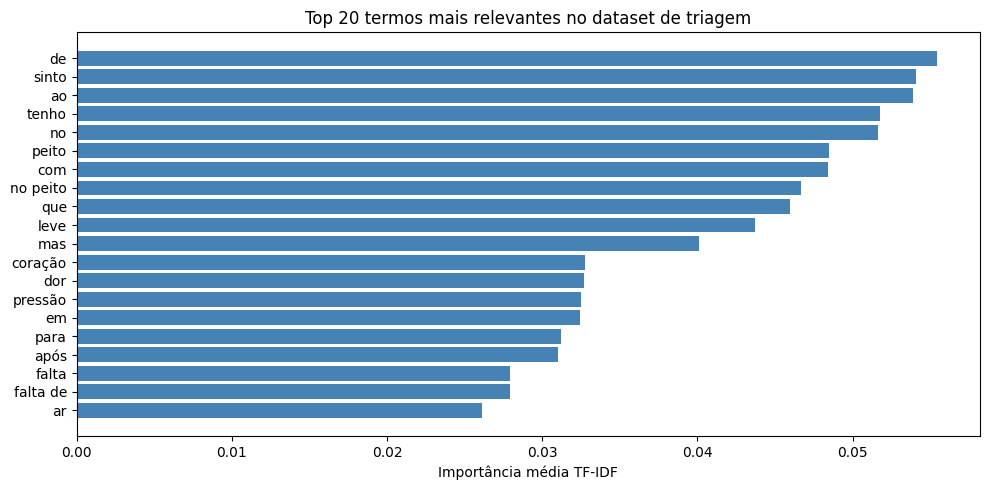

Gráfico salvo como top_termos_tfidf.png


In [17]:
# ─── 6. Top palavras mais importantes (TF-IDF) ───────────────────────────────
# Visualiza quais termos o TF-IDF considerou mais relevantes no dataset.

feature_names = tfidf.get_feature_names_out()

# Média dos valores TF-IDF por feature no conjunto de treino
medias = np.asarray(X_treino_vec.mean(axis=0)).flatten()
top_indices = medias.argsort()[-20:][::-1]
top_palavras = [feature_names[i] for i in top_indices]
top_valores  = medias[top_indices]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_palavras[::-1], top_valores[::-1], color='steelblue')
ax.set_xlabel('Importância média TF-IDF')
ax.set_title('Top 20 termos mais relevantes no dataset de triagem')
plt.tight_layout()
plt.savefig('top_termos_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo como top_termos_tfidf.png')

In [18]:
# ─── 7. Teste com frases novas ────────────────────────────────────────────────
# Simula o uso real do sistema: o médico/enfermeiro digita o relato e recebe a classificação.

# Escolhemos o melhor modelo (Regressão Logística costuma ser mais robusta para texto)
melhor_modelo = resultados_modelos['Regressão Logística']['modelo']

novas_frases = [
    "sinto dor fortíssima no peito com irradiação para o braço e suor frio intenso",
    "tenho um leve cansaço depois de caminhar no parque mas passa com descanso",
    "acordei no meio da noite sem conseguir respirar com o coração acelerado",
    "sinto palpitações leves após tomar energético que somem em alguns minutos",
    "pressão arterial em 210 por 130 com dor de cabeça e visão embaçada"
]

novas_vec = tfidf.transform(novas_frases)
predicoes = melhor_modelo.predict(novas_vec)
probabilidades = melhor_modelo.predict_proba(novas_vec)

print('\nCLASSIFICADOR CARDIAIA – TRIAGEM DE NOVAS FRASES')
print('=' * 65)
classes = melhor_modelo.classes_
for frase, pred, prob in zip(novas_frases, predicoes, probabilidades):
    conf = max(prob)
    alerta = '🚨' if pred == 'alto risco' else '✅'
    print(f'\n{alerta} Frase   : {frase}')
    print(f'   Classificação : {pred.upper()}')
    print(f'   Confiança     : {conf:.1%}')


CLASSIFICADOR CARDIAIA – TRIAGEM DE NOVAS FRASES

🚨 Frase   : sinto dor fortíssima no peito com irradiação para o braço e suor frio intenso
   Classificação : ALTO RISCO
   Confiança     : 64.4%

✅ Frase   : tenho um leve cansaço depois de caminhar no parque mas passa com descanso
   Classificação : BAIXO RISCO
   Confiança     : 69.9%

✅ Frase   : acordei no meio da noite sem conseguir respirar com o coração acelerado
   Classificação : BAIXO RISCO
   Confiança     : 50.6%

✅ Frase   : sinto palpitações leves após tomar energético que somem em alguns minutos
   Classificação : BAIXO RISCO
   Confiança     : 76.4%

✅ Frase   : pressão arterial em 210 por 130 com dor de cabeça e visão embaçada
   Classificação : BAIXO RISCO
   Confiança     : 50.1%


In [19]:
# ─── 8. Análise de viés ───────────────────────────────────────────────────────
# Governança em dados: o modelo pode ter viés por desbalanceamento ou vocabulário limitado.
# Identificamos possíveis pontos de atenção.

print('ANÁLISE DE VIÉS E QUALIDADE DOS DADOS')
print('=' * 50)

dist = triagem['situacao'].value_counts()
total = len(triagem)
for classe, qtd in dist.items():
    print(f'  {classe:15s}: {qtd} amostras ({qtd/total:.1%})')

print()
if abs(dist.iloc[0] - dist.iloc[1]) / total > 0.1:
    print('⚠  ATENÇÃO: Dataset levemente desbalanceado.')
    print('   Em sistemas reais, isso pode fazer o modelo favorecer a classe majoritária.')
    print('   Solução: usar técnicas como SMOTE, oversampling ou ajuste de pesos.')
else:
    print('✅ Dataset relativamente balanceado entre as classes.')

print()
print('Limitações conhecidas deste modelo:')
print('  1. Treinado apenas com português brasileiro informal.')
print('  2. Não considera histórico clínico do paciente.')
print('  3. Frases muito curtas ou com termos fora do vocabulário podem ser mal classificadas.')
print('  4. Não substitui avaliação médica — é um sistema de apoio à decisão (CDSS).')

ANÁLISE DE VIÉS E QUALIDADE DOS DADOS
  baixo risco    : 49 amostras (62.0%)
  alto risco     : 30 amostras (38.0%)

⚠  ATENÇÃO: Dataset levemente desbalanceado.
   Em sistemas reais, isso pode fazer o modelo favorecer a classe majoritária.
   Solução: usar técnicas como SMOTE, oversampling ou ajuste de pesos.

Limitações conhecidas deste modelo:
  1. Treinado apenas com português brasileiro informal.
  2. Não considera histórico clínico do paciente.
  3. Frases muito curtas ou com termos fora do vocabulário podem ser mal classificadas.
  4. Não substitui avaliação médica — é um sistema de apoio à decisão (CDSS).
